# Cross-Dataset Model Analysis (H-CAST Baseline Style)

This notebook mirrors the structure of `hcast_analysis.ipynb`, but compares **models** across **datasets**.

It includes:
- per-dataset validation curves (`FPA`, `wAP`, `TICE`, `AHD`),
- per-dataset training loss curves,
- per-level training/validation curves,
- final test comparison tables.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from model_comparison_utils import (
    ModelComparisonAnalysis,
    ModelComparisonConfig,
    build_model_dataset_run_specs,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT

MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
    'lhdnn': '#d62728',
    'hiercos': '#cad627',
}

# Manual mode: choose run-name tokens here; runs are searched as {model}_{dataset}.
AUTO_DISCOVER = False
DATASET_NAMES = ['cifar100', 'cub200', 'aircraft']  # cifar100, cub200, aircraft, inat21mini
MODEL_NAMES = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']       # hcast, lhdnn, hrn, ht_capsnet, hiercos

MODEL_RUN_NAMES = {
    'ht_capsnet': 'capsnet',
}
DATASET_RUN_NAMES = {
    'inat21-mini': 'inat21mini',
}
MODEL_LABELS = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
    'lhdnn': 'LH-DNN',
    'hiercos': 'HierCoS',
}
DATASET_LABELS = {}
RUN_NAME_OVERRIDES = {}
RUN_LABEL_OVERRIDES = {}
RUN_COLOR_OVERRIDES = {}
EXTRA_RUNS = []

MANUAL_RUNS = build_model_dataset_run_specs(
    MODEL_NAMES,
    DATASET_NAMES,
    model_run_names=MODEL_RUN_NAMES,
    dataset_run_names=DATASET_RUN_NAMES,
    model_labels=MODEL_LABELS,
    dataset_labels=DATASET_LABELS,
    run_name_overrides=RUN_NAME_OVERRIDES,
    run_label_overrides=RUN_LABEL_OVERRIDES,
    run_color_overrides=RUN_COLOR_OVERRIDES,
) + EXTRA_RUNS
MANUAL_RUN_DIRS = []  # Path-only shorthand kept for quick ad hoc additions.

# Optional filters (leave empty = keep everything)
INCLUDE_MODELS = []   # hcast, hrn, ht_capsnet, lhdnn, hiercos
INCLUDE_DATASETS = []  # DATASET_NAMES already selects datasets in manual mode.
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = []

# Use this only when auto-discovering base runs named as model_dataset.
REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT = False

PREFERRED_DATASET_ORDER = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft']
PREFERRED_MODEL_ORDER = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']


In [3]:
config = ModelComparisonConfig(
    output_root=OUTPUT_ROOT,
    auto_discover=AUTO_DISCOVER,
    manual_runs=MANUAL_RUNS,
    manual_run_dirs=MANUAL_RUN_DIRS,
    include_models=INCLUDE_MODELS,
    include_datasets=INCLUDE_DATASETS,
    include_run_name_substrings=INCLUDE_RUN_NAME_SUBSTRINGS,
    exclude_run_name_substrings=EXCLUDE_RUN_NAME_SUBSTRINGS,
    require_model_dataset_run_name_format=REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT,
    preferred_dataset_order=PREFERRED_DATASET_ORDER,
    preferred_model_order=PREFERRED_MODEL_ORDER,
    model_colors=MODEL_COLORS,
)

analysis = ModelComparisonAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/lhdnn_aircraft
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft
Candidate run directories: 13
Parsed runs: 13
Filtered runs: 13

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | best_epoch=93   | best_score=0.7522 | test_FPA_td=74.28%
  - LH-DNN       | run=lhdnn_cifar100                      | best_epoch=14   | best_score=0.4673 | test_FPA_td=45.98%
  - HRN          | run=hrn_cifar100                        | best_epoch=2    | best_score=0.2983 | test_FPA_td=n/a
  - HT-CapsNet   | run=capsnet_cifar100                    | best_epoch=76   | best_score=0.7113 | test_FPA_td=n/a
  - HierCoS      | run=hiercos_cifar100                    | best_epoch=100  | best_score=0.7674 | test_FPA_td=76.19%
CUB-200-2011
  - H-CAST       | run=hcast_cub200                        | best_epoch=99   | best_score=0.8174 | test_FPA_td=80.96%
  - LH-DNN       | r

## Validation Metrics Curves (Per Dataset)

Interpretation note:
- For `FPA` and `wAP`, higher is better.
- For `TICE` and `AHD`, lower is better.
- Solid lines are top-down metrics; dashed lines are independent metrics.


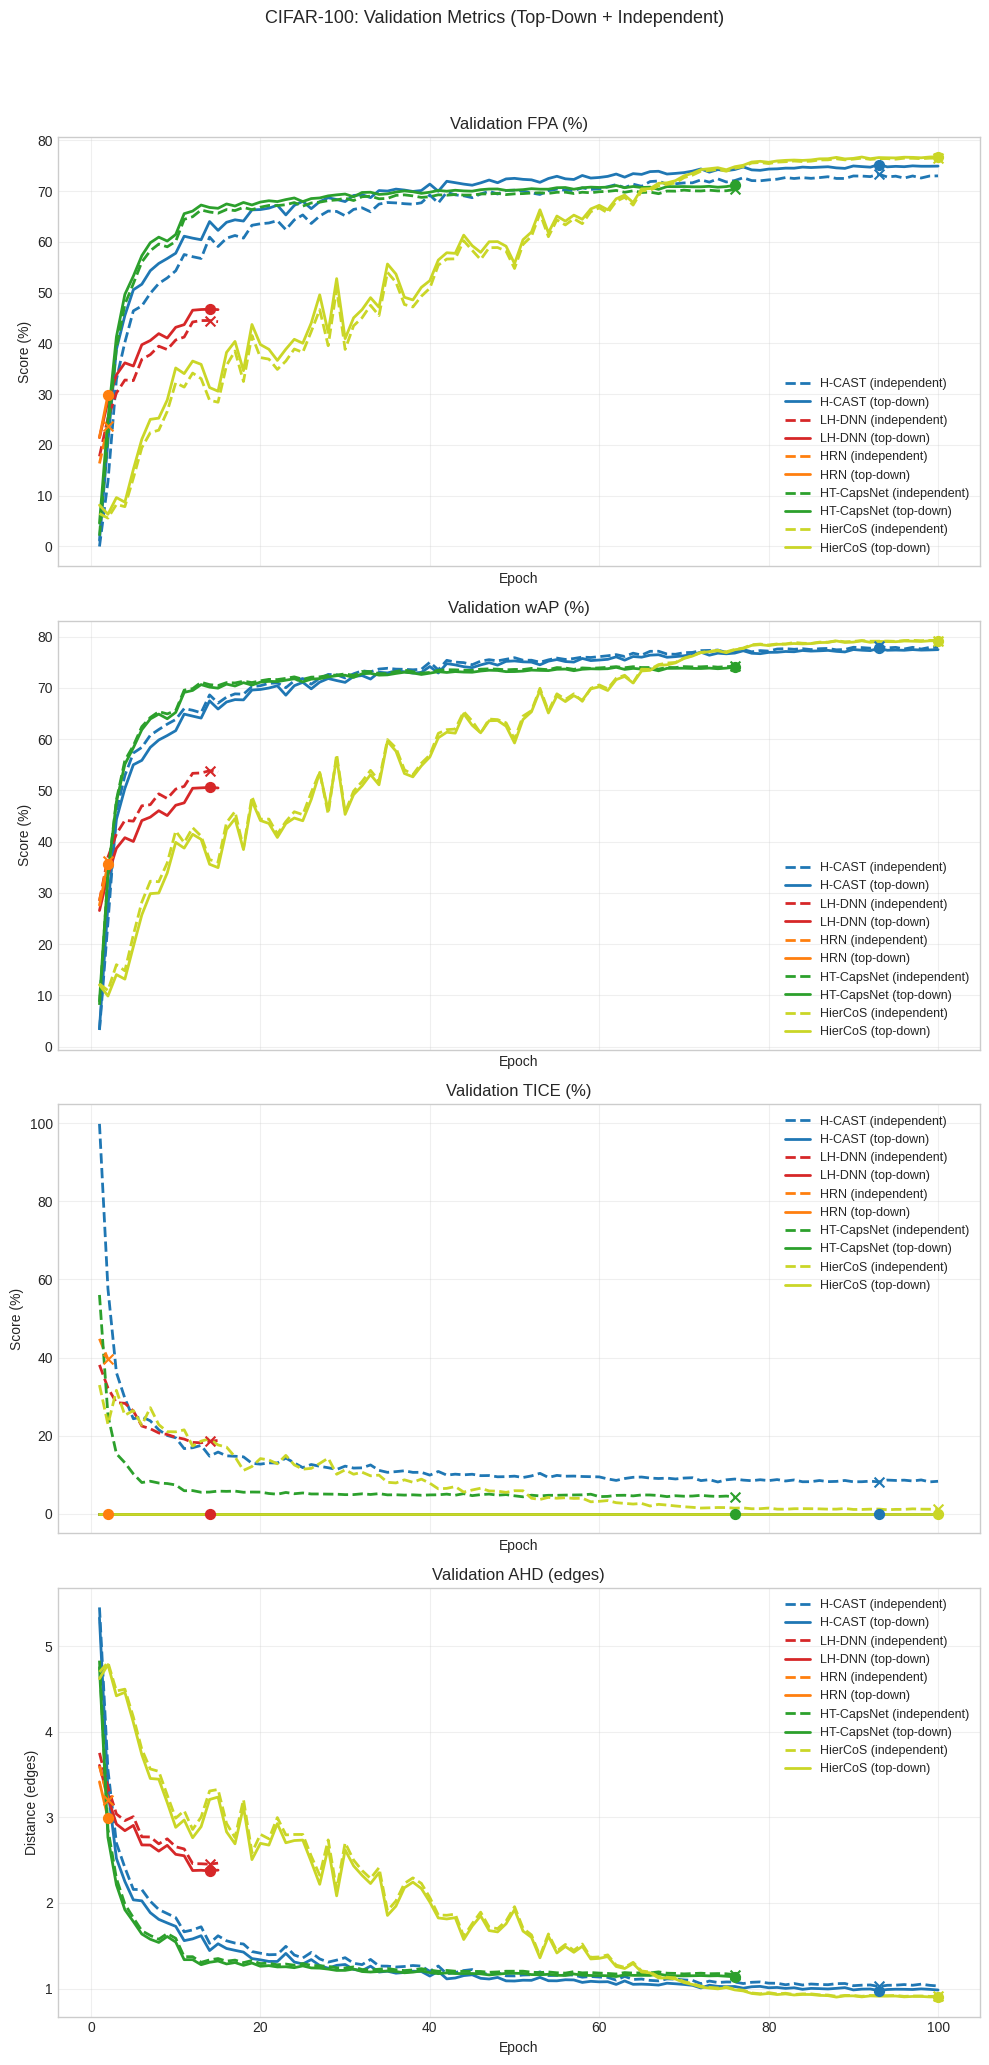

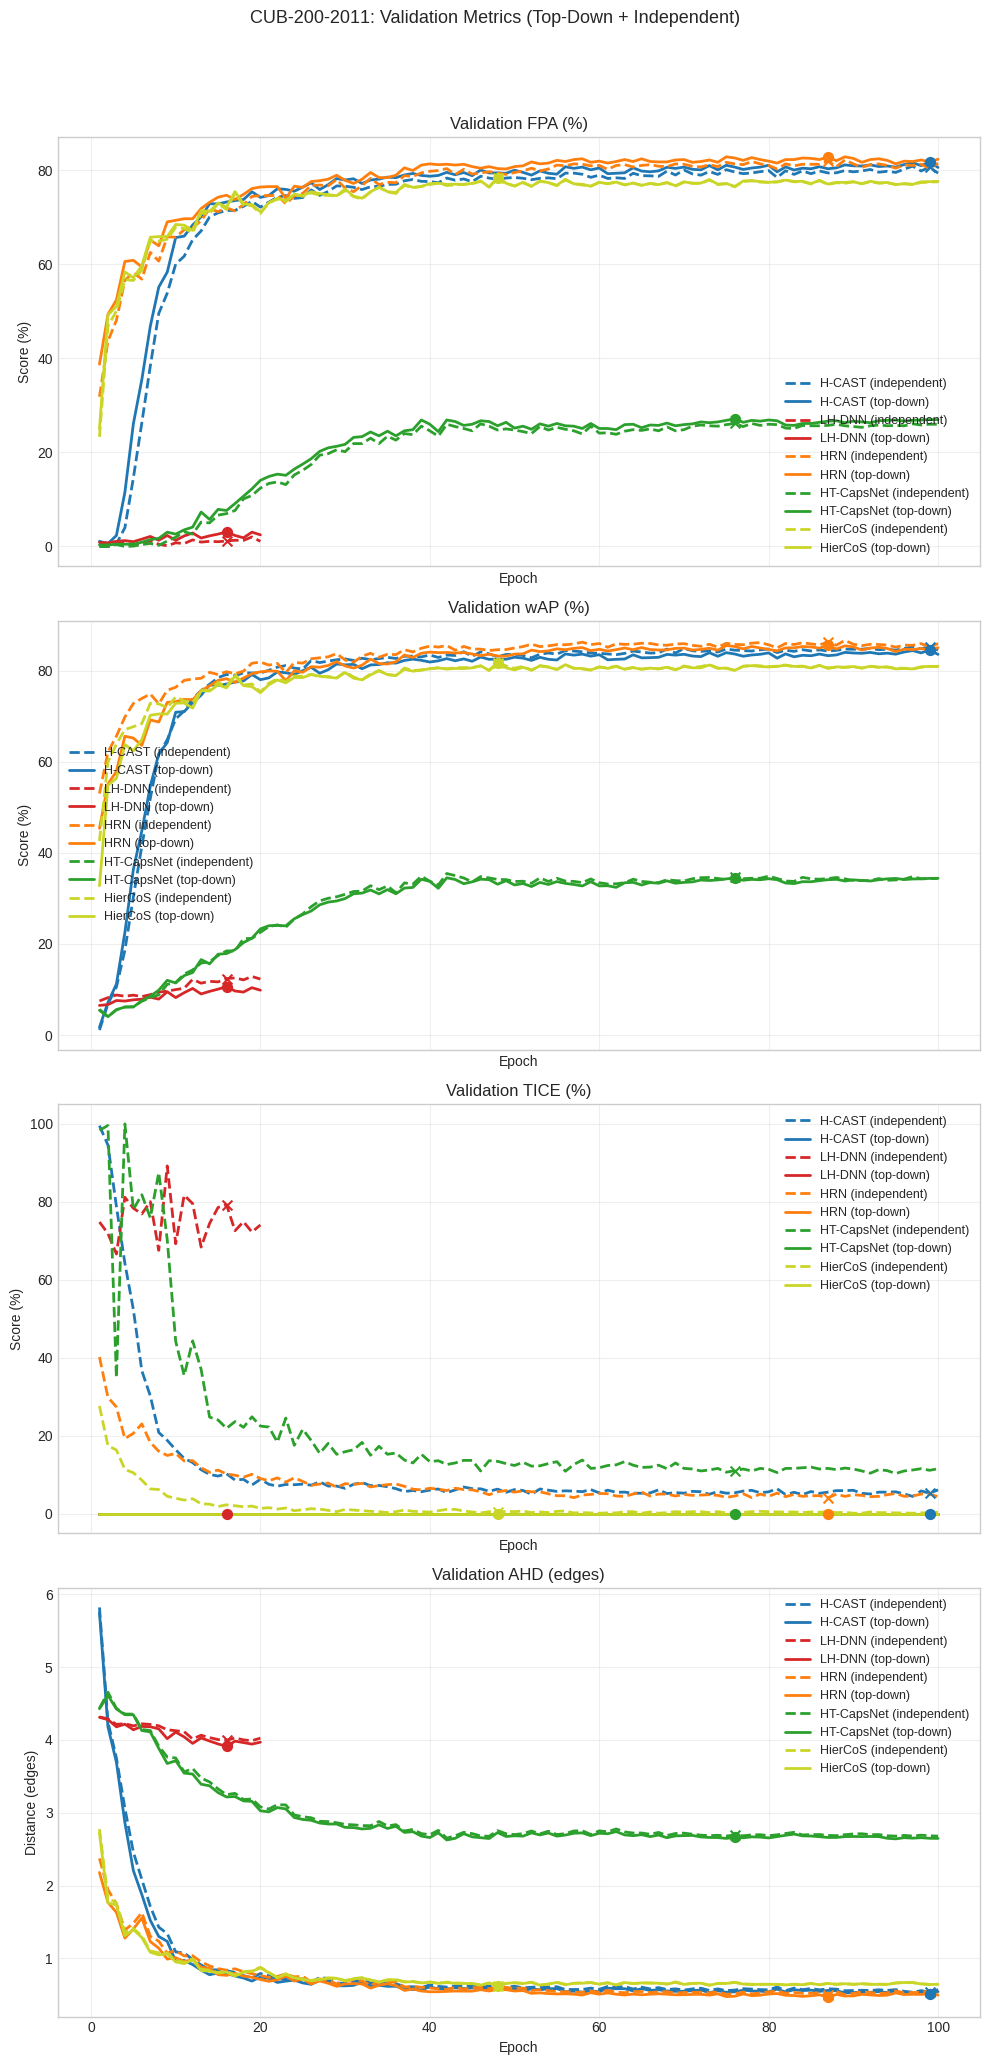

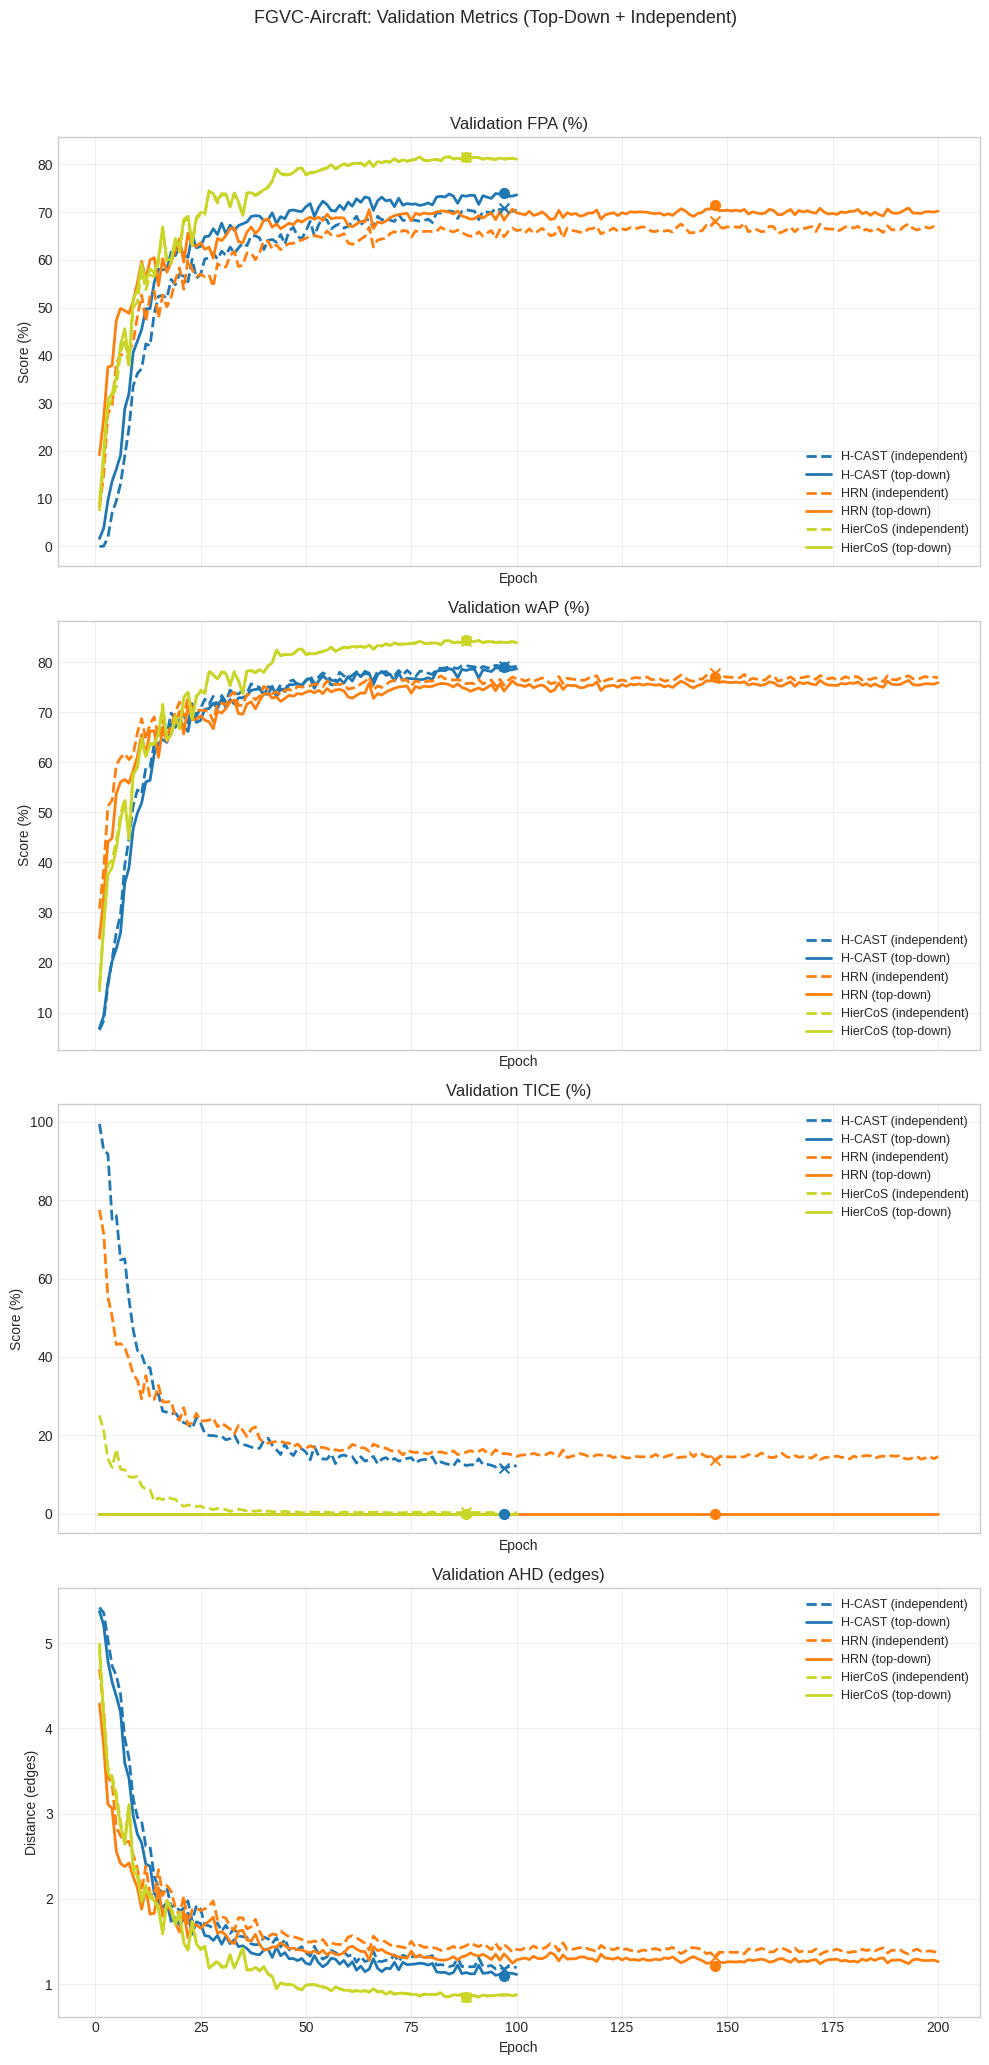

In [4]:
analysis.plot_validation_curves()


## Training Loss Comparison (Per Dataset)

Interpretation note:
- Lower is better for all loss curves.


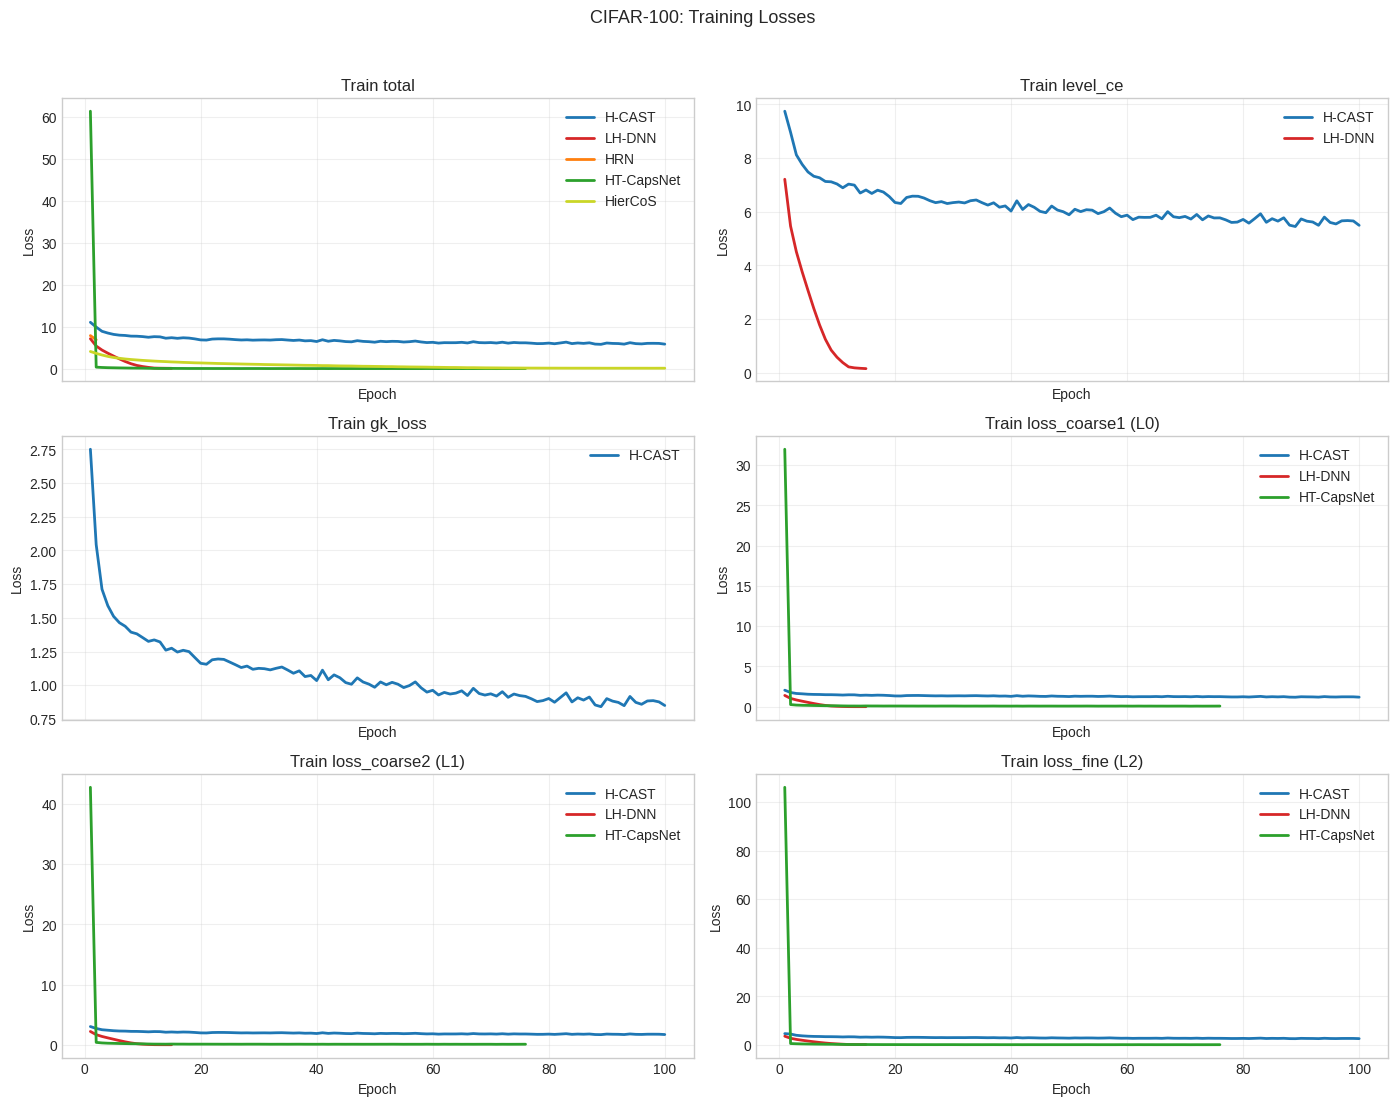

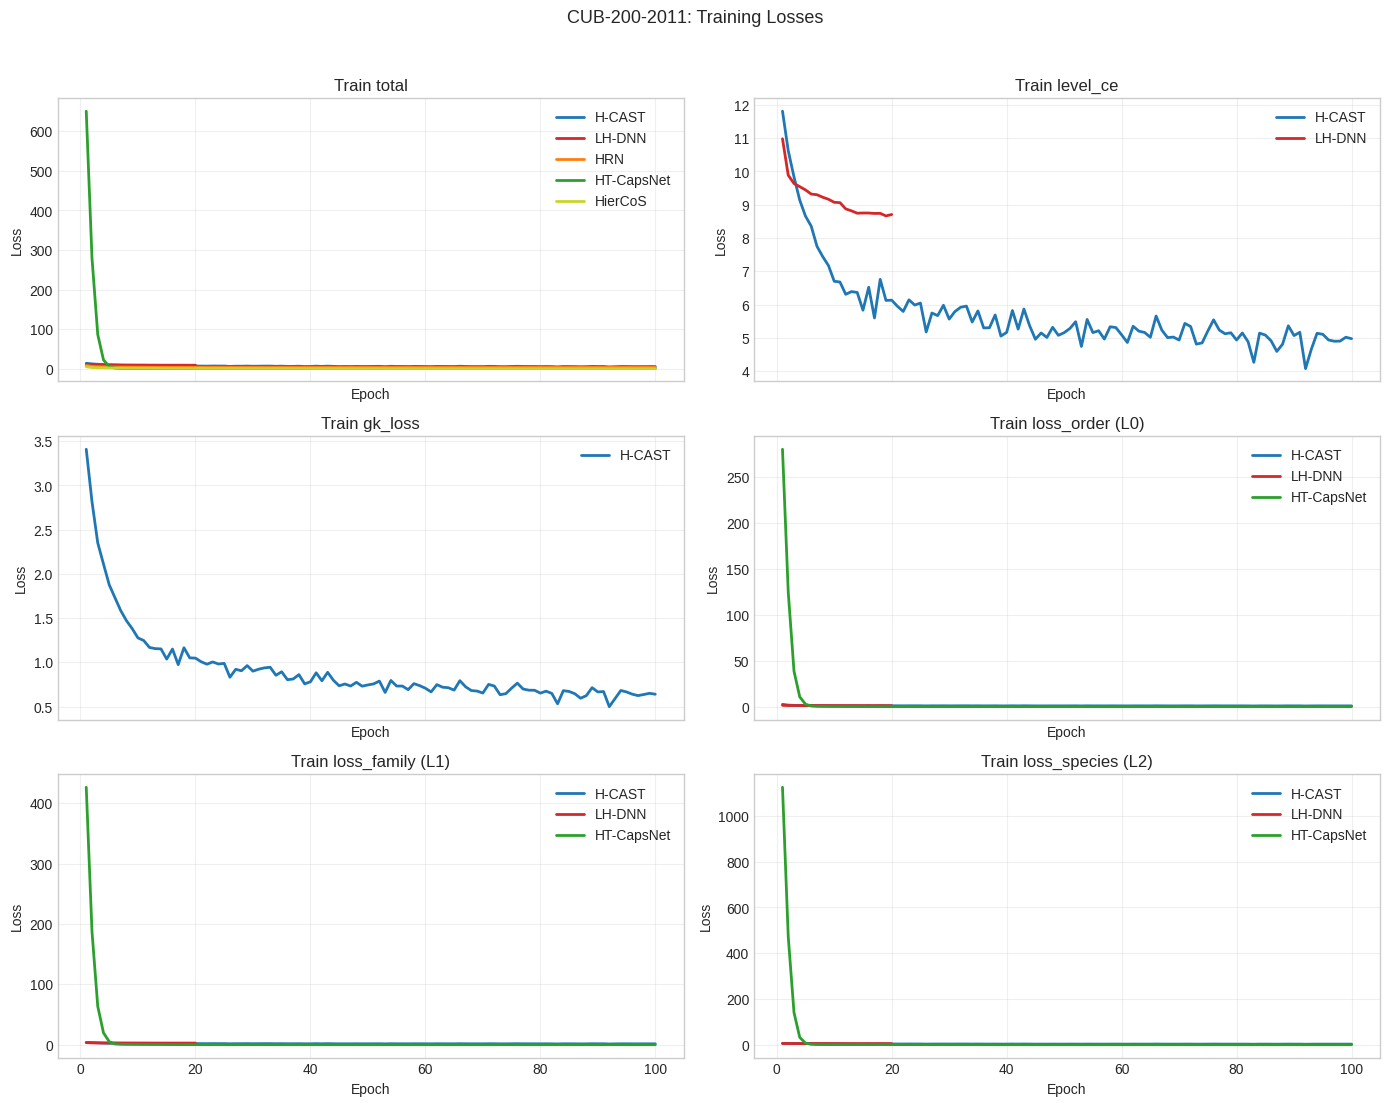

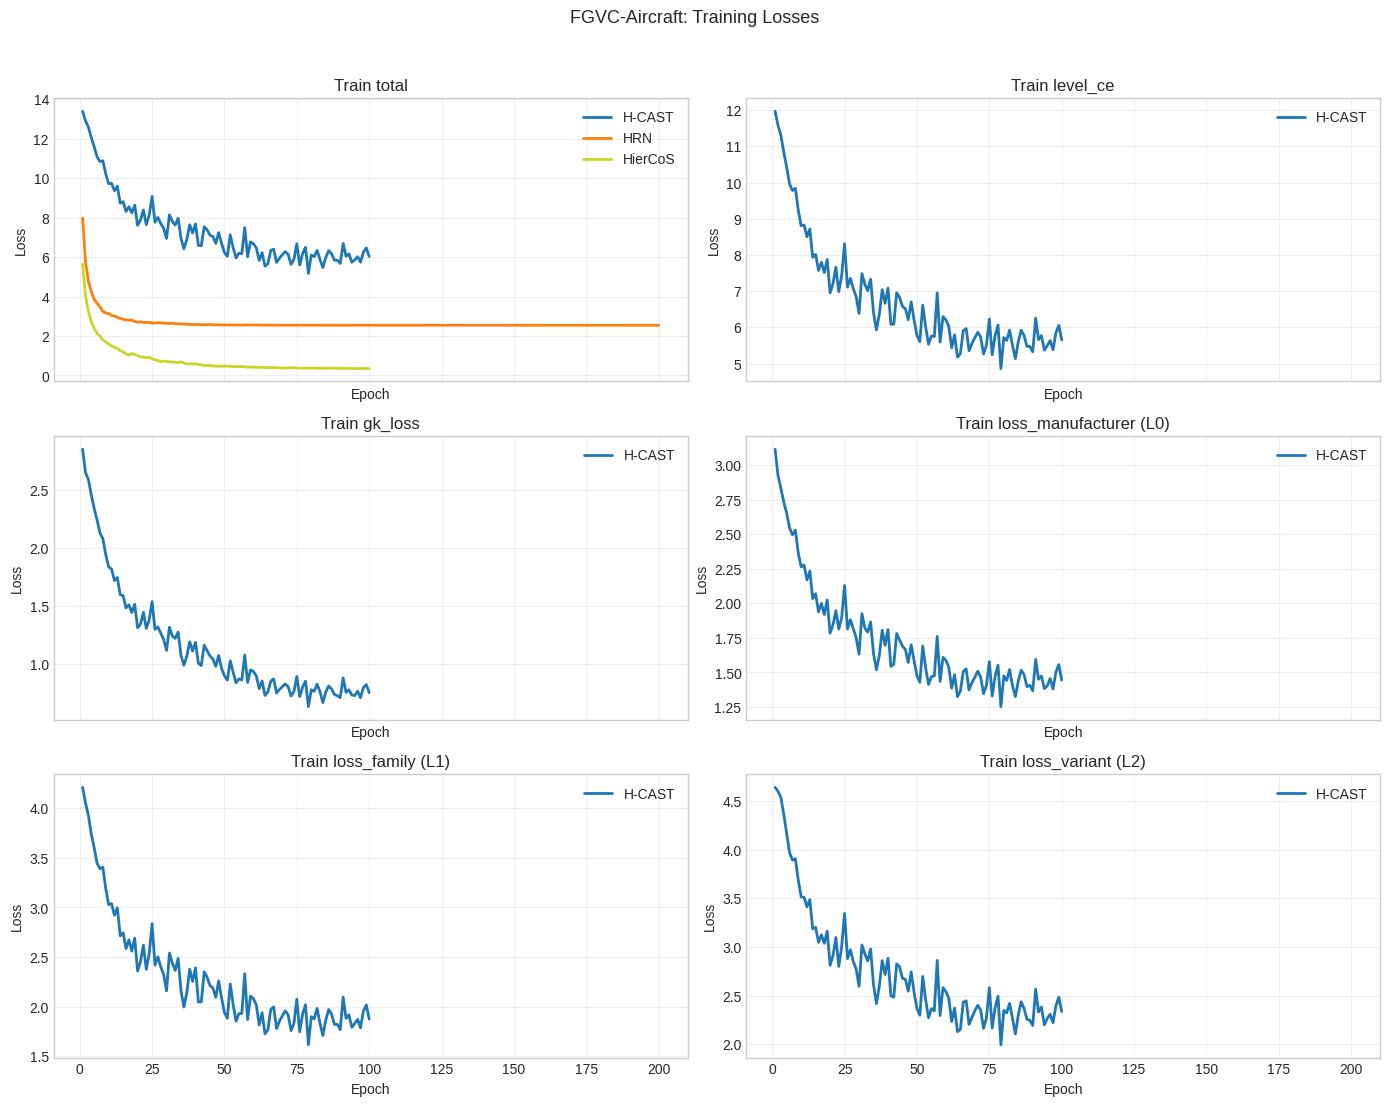

In [5]:
analysis.plot_training_losses_per_dataset()


## Per-Level Training Losses (Per Model and Dataset)

Interpretation note:
- Each chart corresponds to one selected `(model, dataset)` run.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).


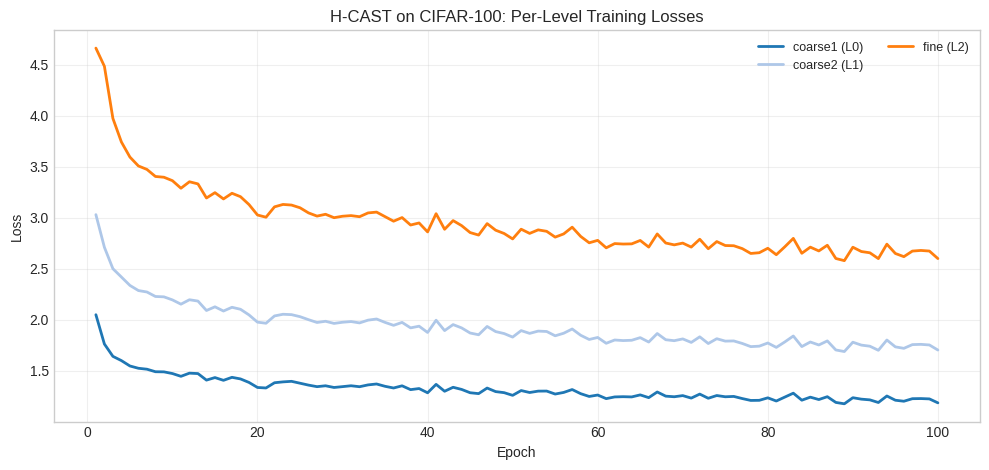

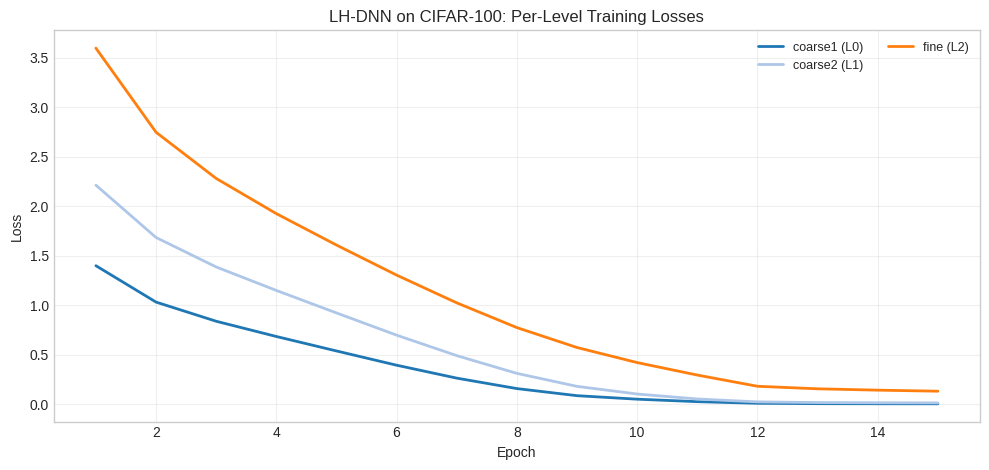

No per-level train losses for HRN on CIFAR-100


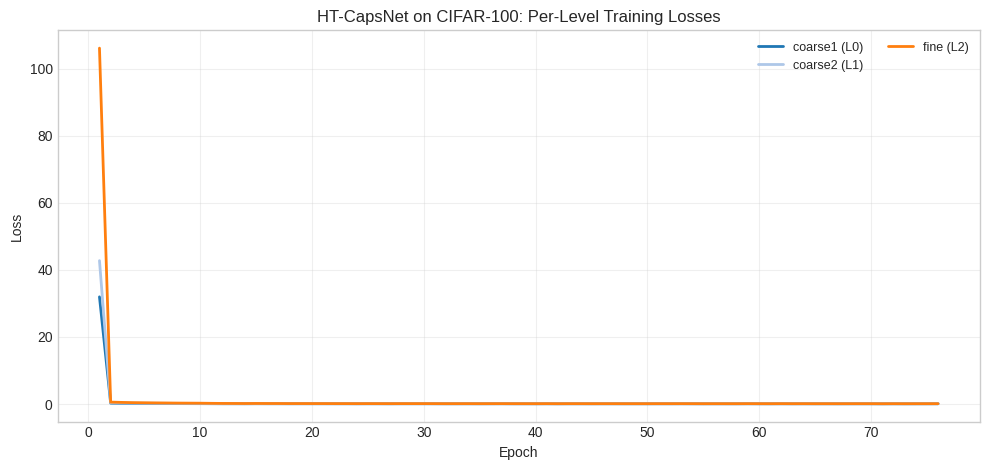

No per-level train losses for HierCoS on CIFAR-100


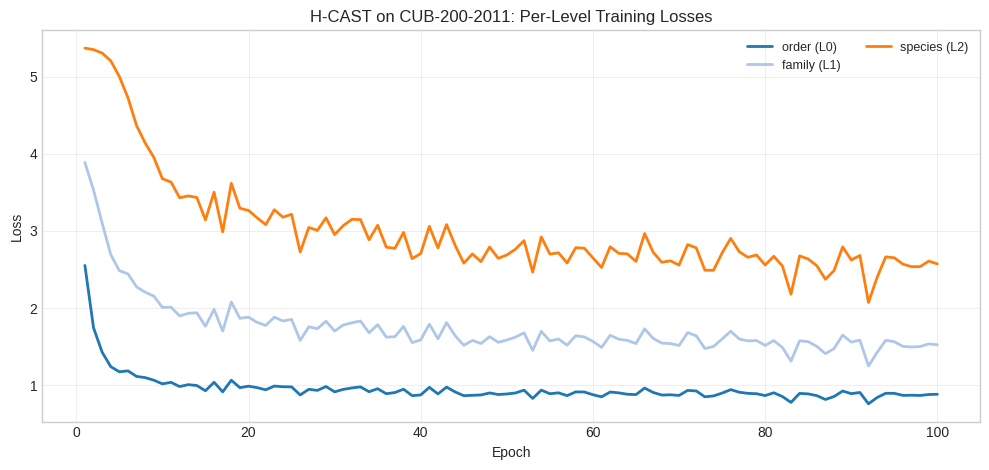

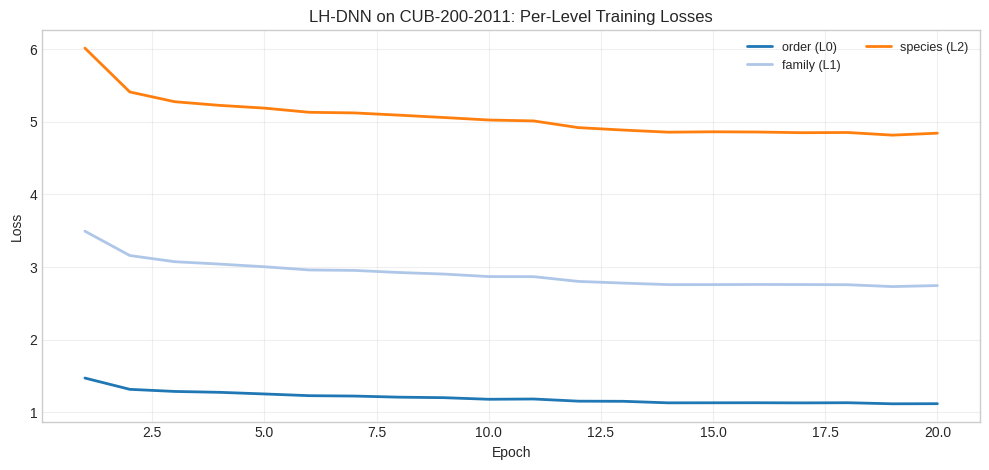

No per-level train losses for HRN on CUB-200-2011


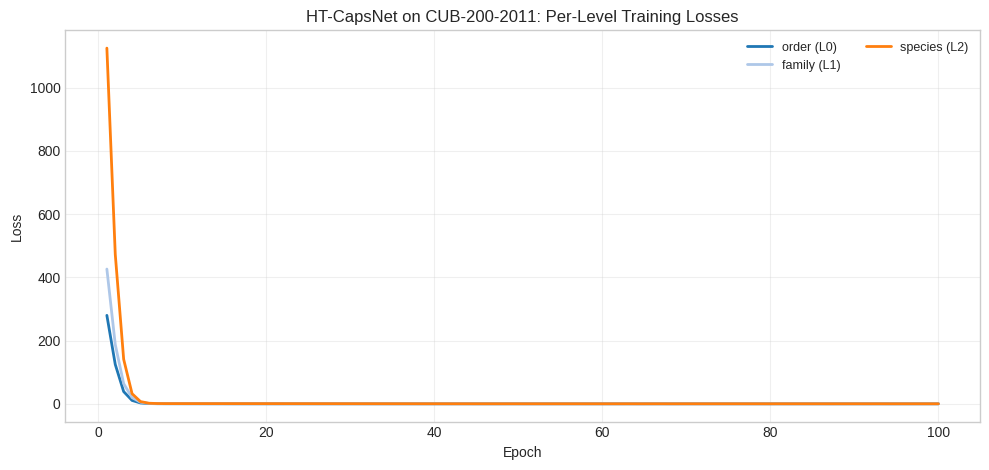

No per-level train losses for HierCoS on CUB-200-2011


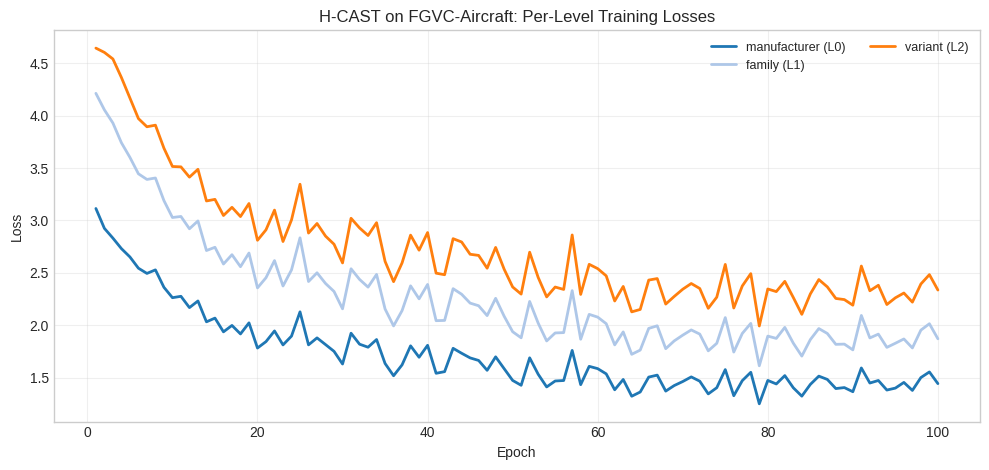

No per-level train losses for HRN on FGVC-Aircraft
No per-level train losses for HierCoS on FGVC-Aircraft


In [6]:
analysis.plot_per_run_per_level_training_losses()


## Per-Level Validation Accuracy (Top-Down and Independent)

Interpretation note:
- Solid vs dashed of the same color shows top-down vs independent for the same model.


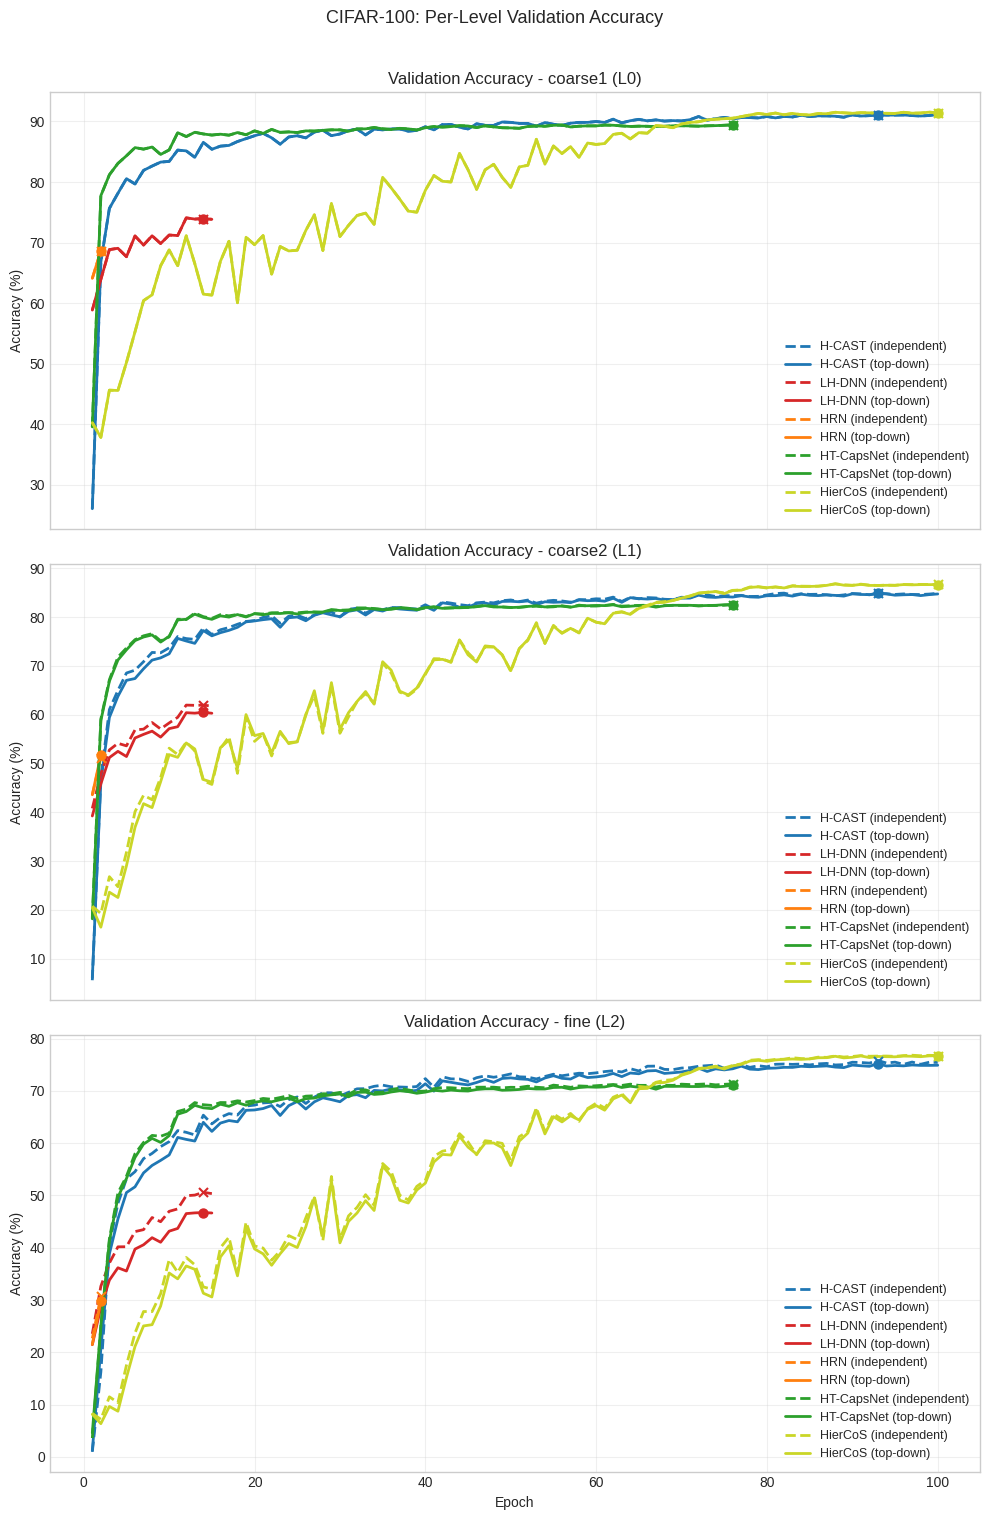

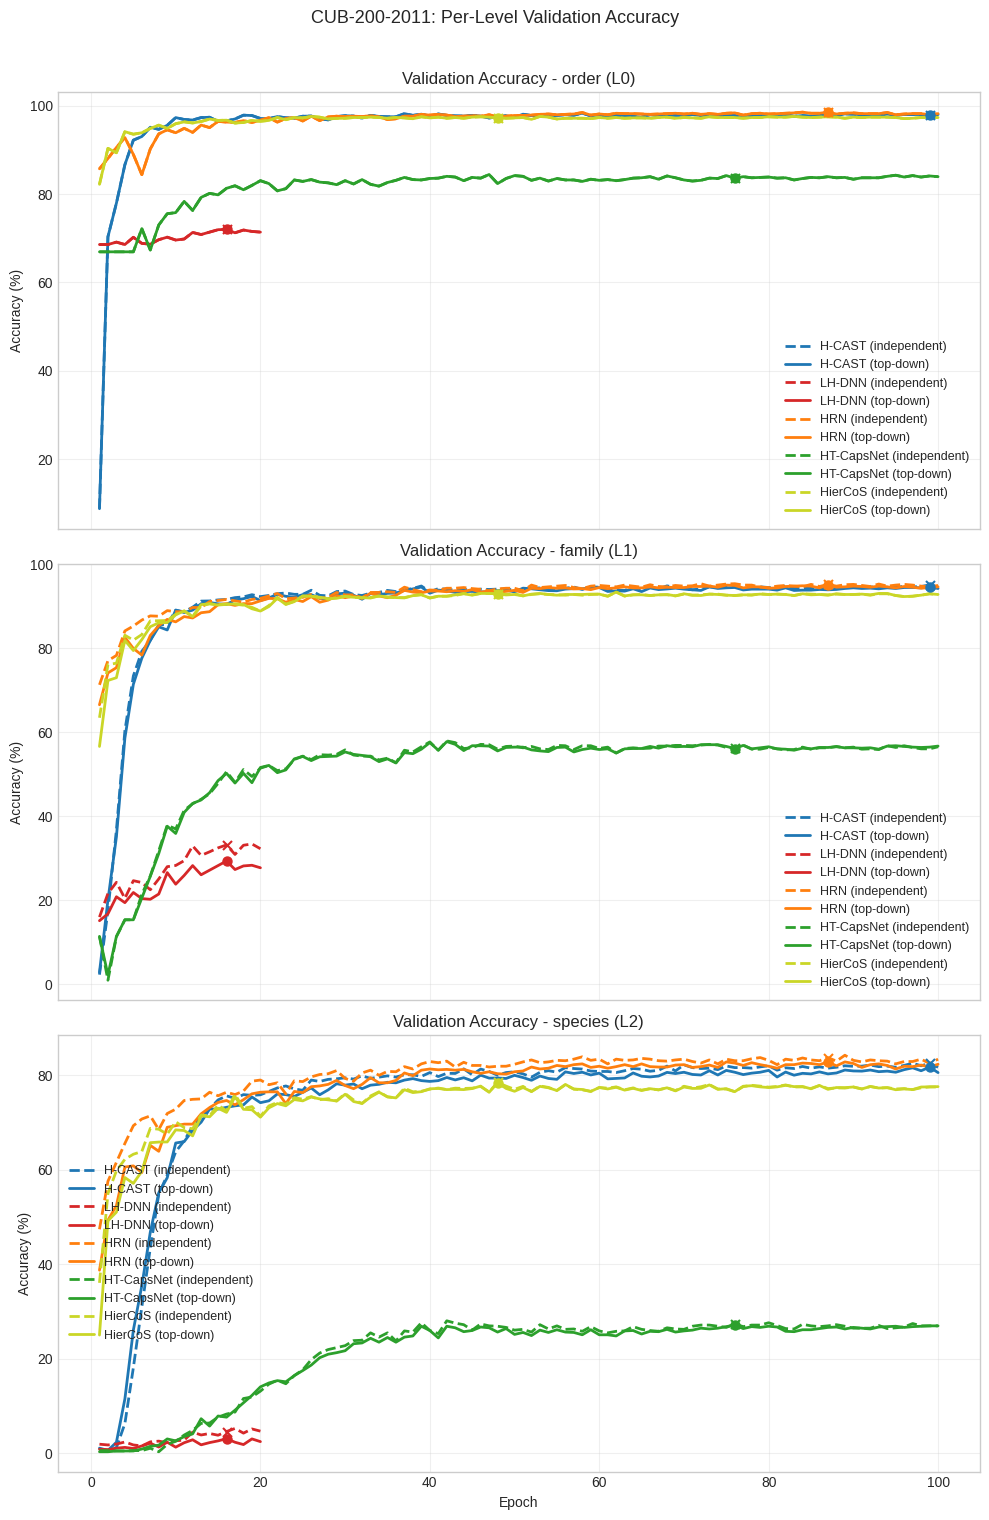

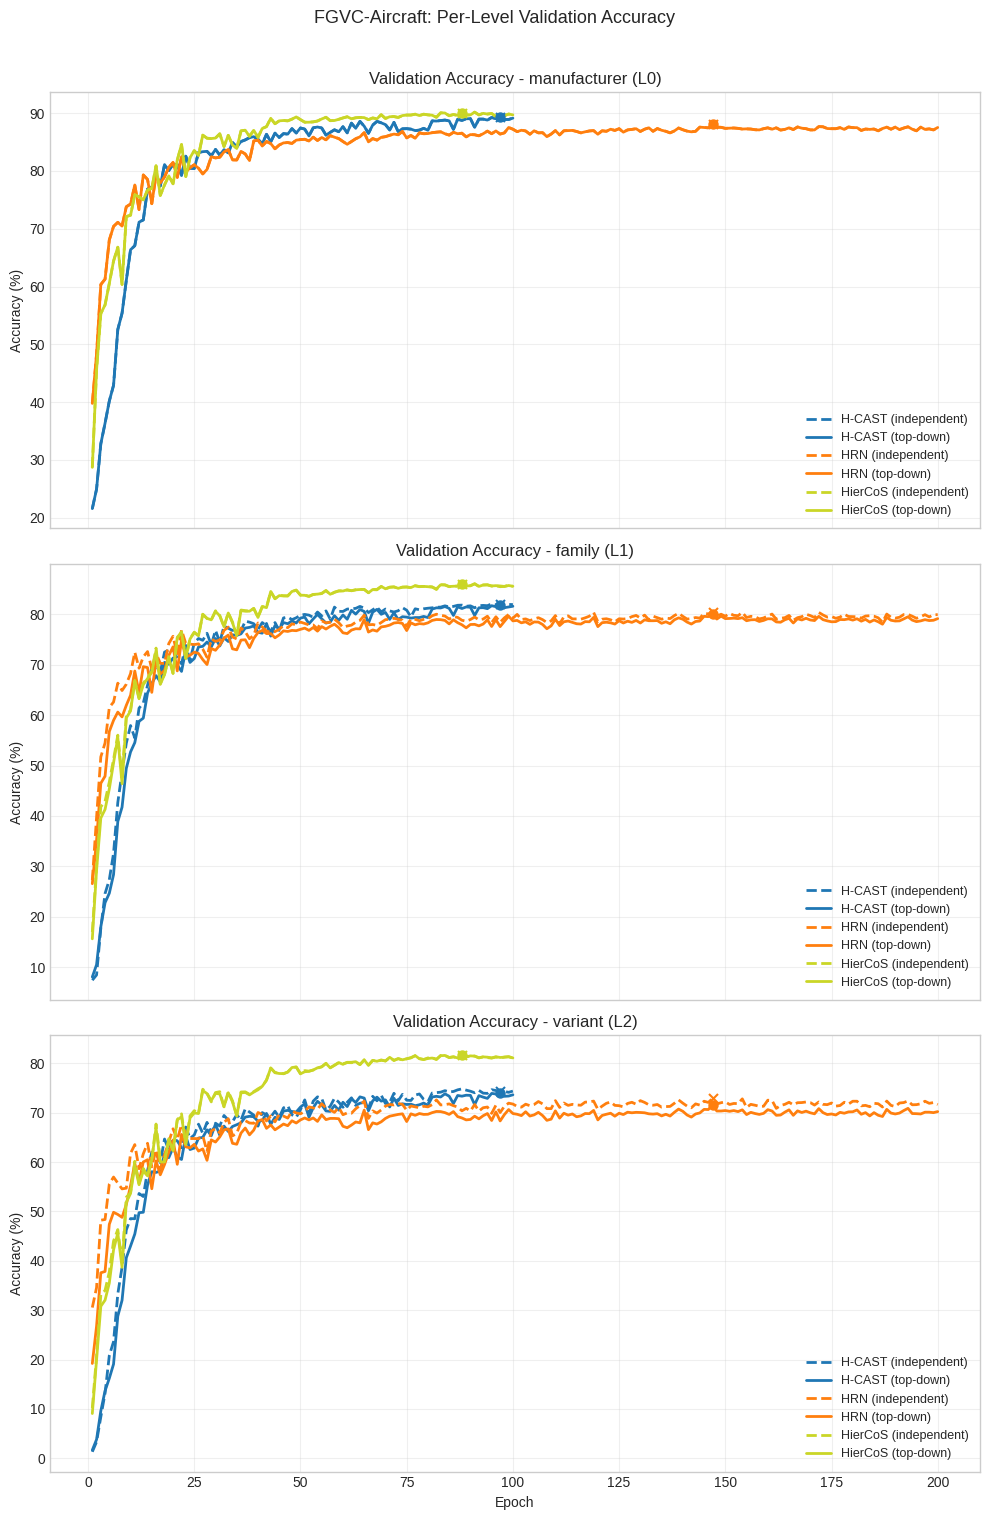

In [7]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Tables (Per Dataset)

The first model in each dataset section is used as baseline for deltas.


In [8]:
analysis.show_final_test_tables()


### Dataset: `CIFAR-100`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet | HierCoS |
|---|---:|---:|---:|---:|---:|
| FPA independent ↑ | 72.39% | 43.83% (-28.56 pp) | n/a | n/a | **75.95% (+3.55 pp)** |
| FPA top-down ↑ | 74.28% | 45.98% (-28.30 pp) | n/a | n/a | **76.19% (+1.92 pp)** |
| wAP independent ↑ | 77.63% | 53.16% (-24.46 pp) | n/a | n/a | **78.64% (+1.02 pp)** |
| wAP top-down ↑ | 76.91% | 49.84% (-27.06 pp) | n/a | n/a | **78.60% (+1.70 pp)** |
| TICE independent ↓ | 8.32% | 18.38% (+10.06 pp) | n/a | n/a | **1.18% (-7.14 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | n/a | n/a | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.059 | 2.488 (+1.429) | n/a | n/a | **0.955 (-0.104)** |
| AHD top-down ↓ | 1.011 | 2.416 (+1.405) | n/a | n/a | **0.948 (-0.063)** |
| Acc independent coarse1 (L0) ↑ | **90.59%** | 73.51% (-17.08 pp) | n/a | n/a | 90.58% (-0.01 pp) |
| Acc top-down coarse1 (L0) ↑ | **90.59%** | 73.51% (-17.08 pp) | n/a | n/a | 90.58% (-0.01 pp) |
| Acc independent coarse2 (L1) ↑ | 84.59% | 61.52% (-23.07 pp) | n/a | n/a | **85.86% (+1.27 pp)** |
| Acc top-down coarse2 (L1) ↑ | 84.58% | 59.71% (-24.87 pp) | n/a | n/a | **85.85% (+1.27 pp)** |
| Acc independent fine (L2) ↑ | 75.20% | 49.86% (-25.33 pp) | n/a | n/a | **76.24% (+1.05 pp)** |
| Acc top-down fine (L2) ↑ | 74.28% | 45.98% (-28.30 pp) | n/a | n/a | **76.19% (+1.92 pp)** |

### Dataset: `CUB-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST | LH-DNN | HRN | HT-CapsNet | HierCoS |
|---|---:|---:|---:|---:|---:|
| FPA independent ↑ | 79.27% | 1.66% (-77.60 pp) | **82.05% (+2.78 pp)** | 25.34% (-53.93 pp) | 75.99% (-3.28 pp) |
| FPA top-down ↑ | 80.96% | 3.36% (-77.60 pp) | **83.24% (+2.29 pp)** | 26.30% (-54.65 pp) | 76.11% (-4.85 pp) |
| wAP independent ↑ | 84.17% | 13.23% (-70.94 pp) | **86.55% (+2.38 pp)** | 34.24% (-49.93 pp) | 79.48% (-4.69 pp) |
| wAP top-down ↑ | 83.73% | 11.04% (-72.70 pp) | **85.64% (+1.91 pp)** | 33.89% (-49.85 pp) | 79.44% (-4.29 pp) |
| TICE independent ↓ | 6.10% | 76.27% (+70.17 pp) | 5.36% (-0.74 pp) | 11.80% (+5.70 pp) | **0.50% (-5.60 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.587 | 3.967 (+3.380) | **0.524 (-0.063)** | 2.689 (+2.101) | 0.722 (+0.135) |
| AHD top-down ↓ | 0.550 | 3.891 (+3.341) | **0.491 (-0.060)** | 2.660 (+2.109) | 0.718 (+0.167) |
| Acc independent order (L0) ↑ | 98.08% | 71.23% (-26.85 pp) | **98.31% (+0.23 pp)** | 84.10% (-13.98 pp) | 97.03% (-1.05 pp) |
| Acc top-down order (L0) ↑ | 98.08% | 71.23% (-26.85 pp) | **98.31% (+0.23 pp)** | 84.10% (-13.98 pp) | 97.03% (-1.05 pp) |
| Acc independent family (L1) ↑ | 93.57% | 34.48% (-59.09 pp) | **93.76% (+0.18 pp)** | 56.75% (-36.83 pp) | 90.94% (-2.64 pp) |
| Acc top-down family (L1) ↑ | 93.44% | 30.85% (-62.59 pp) | **93.91% (+0.47 pp)** | 56.61% (-36.83 pp) | 90.97% (-2.47 pp) |
| Acc independent species (L2) ↑ | 81.48% | 5.42% (-76.06 pp) | **84.41% (+2.94 pp)** | 26.72% (-54.76 pp) | 76.16% (-5.32 pp) |
| Acc top-down species (L2) ↑ | 80.96% | 3.36% (-77.60 pp) | **83.24% (+2.29 pp)** | 26.30% (-54.65 pp) | 76.11% (-4.85 pp) |

### Dataset: `FGVC-Aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HRN | HierCoS |
|---|---:|---:|---:|
| FPA independent ↑ | 69.41% | 69.62% (+0.21 pp) | **82.19% (+12.78 pp)** |
| FPA top-down ↑ | 72.31% | 72.70% (+0.39 pp) | **82.22% (+9.91 pp)** |
| wAP independent ↑ | 78.62% | 79.11% (+0.49 pp) | **84.85% (+6.23 pp)** |
| wAP top-down ↑ | 77.23% | 77.88% (+0.66 pp) | **84.84% (+7.62 pp)** |
| TICE independent ↓ | 13.32% | 12.89% (-0.43 pp) | **0.32% (-13.00 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.282 | 1.265 (-0.018) | **0.828 (-0.455)** |
| AHD top-down ↓ | 1.208 | 1.162 (-0.046) | **0.827 (-0.381)** |
| Acc independent manufacturer (L0) ↑ | 87.38% | 88.41% (+1.03 pp) | **90.06% (+2.69 pp)** |
| Acc top-down manufacturer (L0) ↑ | 87.38% | 88.41% (+1.03 pp) | **90.06% (+2.69 pp)** |
| Acc independent family (L1) ↑ | 81.44% | 81.61% (+0.17 pp) | **86.38% (+4.94 pp)** |
| Acc top-down family (L1) ↑ | 79.90% | 80.77% (+0.87 pp) | **86.35% (+6.45 pp)** |
| Acc independent variant (L2) ↑ | 74.02% | 74.56% (+0.54 pp) | **82.22% (+8.21 pp)** |
| Acc top-down variant (L2) ↑ | 72.31% | 72.70% (+0.39 pp) | **82.22% (+9.91 pp)** |